# Adult Income Data Cleaning & Exploratory Data Analysis

## 1. Project Overview

This project performs data cleaning and exploratory data analysis (EDA) on the
UCI Adult Income dataset.

The objective is to understand which demographic, educational, and employment
characteristics are associated with an annual income above USD 50K.

This project covers the complete data analysis workflow:

- Data collection
- Raw data inspection
- Data cleaning
- Missing-value handling
- Data validation
- Feature engineering
- Exploratory data analysis
- Data visualization
- Findings and interpretation
- Limitations

### Business Question

> Which demographic, education, and work characteristics are associated with
> an annual income above USD 50K in this census dataset?

### Analysis Approach

This is a **descriptive analysis**. The results identify patterns and
associations within the dataset but do not establish causal relationships.

### Dataset Source

**UCI Machine Learning Repository — Adult Dataset**

The analysis uses the official:

- `adult.data`
- `adult.test`

files provided by the UCI Machine Learning Repository.

## 2. Import Libraries

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Data Collection

The Adult Income dataset is obtained from the UCI Machine Learning Repository.

The original dataset is provided in two files:

- `adult.data` — training data
- `adult.test` — test data

Both files are downloaded from the official UCI source and stored in the
`data/raw/` directory without modifying their original contents.

In [2]:
from pathlib import Path
import requests

# Create the raw data directory
raw_dir = Path("data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

# Official UCI dataset URLs
urls = {
    "adult.data": "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    "adult.test": "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"
}

# Download each file
for filename, url in urls.items():
    file_path = raw_dir / filename
    
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    
    file_path.write_bytes(response.content)
    
    print(f"Downloaded: {filename}")

print("\nRaw data files downloaded successfully!")

Downloaded: adult.data
Downloaded: adult.test

Raw data files downloaded successfully!


## 4. Raw Data Inspection

Before cleaning the dataset, we inspect the raw files to understand their
structure, dimensions, column values, data types, missing-value representation,
and potential duplicate records.

The UCI Adult dataset uses `?` to represent missing categorical values.

In [3]:
# Define column names from the UCI Adult dataset
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

# Load the raw training and test files
train_df = pd.read_csv(
    "data/raw/adult.data",
    names=columns,
    skipinitialspace=True
)

test_df = pd.read_csv(
    "data/raw/adult.test",
    names=columns,
    skipinitialspace=True,
    skiprows=1
)

print("Training records:", len(train_df))
print("Test records:", len(test_df))
print("Total records:", len(train_df) + len(test_df))

Training records: 32561
Test records: 16281
Total records: 48842


In [4]:
train_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Total records:", len(train_df) + len(test_df))

Training shape: (32561, 15)
Test shape: (16281, 15)
Total records: 48842


In [6]:
test_df.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.


In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


### 4.1 Missing-Value Marker Inspection

The raw UCI Adult dataset represents missing categorical values using the
`?` character. Because pandas reads `?` as ordinary text, these values are
not automatically counted as missing values.

We therefore inspect the frequency of `?` before converting it to a
standard missing-value representation.

In [8]:
# Count '?' values in each column

missing_marker_counts = (train_df == "?").sum()

missing_marker_counts[missing_marker_counts > 0]

workclass         1836
occupation        1843
native_country     583
dtype: int64

In [9]:
missing_marker_counts_test = (test_df == "?").sum()

missing_marker_counts_test[missing_marker_counts_test > 0]

workclass         963
occupation        966
native_country    274
dtype: int64

### 4.2 Duplicate Audit

Exact duplicate rows are counted to understand the raw data quality.

Duplicates are not automatically removed because the dataset does not contain
a unique person identifier. Therefore, identical records cannot be assumed to
represent accidental duplicate observations.

In [10]:
# Count exact duplicate rows

print("Training duplicate rows:", train_df.duplicated().sum())
print("Test duplicate rows:", test_df.duplicated().sum())

Training duplicate rows: 24
Test duplicate rows: 5


## 5. Combine Raw Dataset Partitions

The UCI Adult dataset is provided as separate training and test files.

For this descriptive analysis, the two partitions are combined into a single
analysis dataset. A `source_split` column is retained to preserve the origin
of each record and maintain data traceability.

No cleaning or modification is performed during this step.

In [11]:
# Add source information before combining the datasets

train_df["source_split"] = "train"
test_df["source_split"] = "test"

# Combine the two raw datasets
adult_df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

print("Combined dataset shape:", adult_df.shape)

Combined dataset shape: (48842, 16)


In [12]:
adult_df["source_split"].value_counts()

source_split
train    32561
test     16281
Name: count, dtype: int64

In [13]:
adult_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source_split
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train


# 6. Data Cleaning

The raw dataset contains formatting inconsistencies and missing-value markers
that need to be addressed before exploratory analysis.

The cleaning process includes:

- Standardizing column names
- Removing unnecessary whitespace
- Converting `?` markers to missing values
- Handling missing categorical values
- Normalizing income labels
- Validating numerical columns
- Checking for impossible values
- Creating analysis-ready features

## 6.1 Standardize Column Names

Column names are standardized to lowercase `snake_case` to make them
consistent and easier to work with in Python.

In [14]:
# Standardize column names

adult_df.columns = (
    adult_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

adult_df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income', 'source_split'],
      dtype='str')

### 6.2 Standardize Text Values

Leading and trailing whitespace is removed from all text columns.

This prevents values such as `" Private"` and `"Private"` from being treated
as different categories.

In [15]:
# Remove leading and trailing whitespace from all text columns

text_columns = adult_df.select_dtypes(include=["str"]).columns

adult_df[text_columns] = adult_df[text_columns].apply(
    lambda col: col.str.strip()
)

print("Whitespace standardization completed.")

Whitespace standardization completed.


### 6.3 Convert Missing-Value Markers

The UCI Adult dataset uses `?` to represent missing categorical values.

These markers are converted to pandas `NaN` so that missing values can be
identified and handled consistently.

In [16]:
# Convert '?' markers to standard missing values

adult_df = adult_df.replace("?", np.nan)

print("Missing-value markers converted to NaN.")

Missing-value markers converted to NaN.


In [17]:
adult_df.isna().sum().sort_values(ascending=False)

occupation        2809
workclass         2799
native_country     857
fnlwgt               0
education            0
education_num        0
marital_status       0
age                  0
relationship         0
race                 0
capital_gain         0
sex                  0
capital_loss         0
hours_per_week       0
income               0
source_split         0
dtype: int64

## 6.4 Handle Missing Categorical Values

Missing values are present in `workclass`, `occupation`, and `native_country`.

Instead of removing these records, missing categorical values are replaced
with `Unknown`. This preserves the observations while making the missingness
explicit for subsequent analysis.

In [18]:
# Handle missing categorical values

categorical_missing_columns = [
    "workclass",
    "occupation",
    "native_country"
]

adult_df[categorical_missing_columns] = (
    adult_df[categorical_missing_columns]
    .fillna("Unknown")
)

print("Missing categorical values replaced with 'Unknown'.")

Missing categorical values replaced with 'Unknown'.


In [19]:
adult_df[categorical_missing_columns].isna().sum()

workclass         0
occupation        0
native_country    0
dtype: int64

## 6.5 Normalize Income Labels

The training and test files use slightly different representations of the
income labels. The test file contains a trailing period (`.`).

The trailing period is removed so that both partitions use the same two
categories:

- `<=50K`
- `>50K`

In [20]:
# Remove trailing periods and standardize income labels

adult_df["income"] = (
    adult_df["income"]
    .str.strip()
    .str.rstrip(".")
)

print(adult_df["income"].value_counts())

income
<=50K    37155
>50K     11687
Name: count, dtype: int64


## 6.6 Create High-Income Flag

A binary `high_income` feature is created from the cleaned `income` label.

- `0` → income is `<=50K`
- `1` → income is `>50K`

This numerical representation will make it easier to calculate proportions
and compare income rates across different groups.

In [21]:
# Create binary high-income flag

adult_df["high_income"] = (
    adult_df["income"]
    .eq(">50K")
    .astype(int)
)

print(adult_df["high_income"].value_counts())

high_income
0    37155
1    11687
Name: count, dtype: int64


In [22]:
adult_df[["income", "high_income"]].drop_duplicates().sort_values("income")

,income,high_income
0,<=50K,0
7,>50K,1


In [23]:
adult_df["income"].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [24]:
adult_df["high_income"].value_counts()

high_income
0    37155
1    11687
Name: count, dtype: int64

## 6.7 Validate Numeric Columns

The dataset contains several numerical variables, including age, census
weight, education level, capital gains, capital losses, and weekly working
hours.

These columns are checked to ensure they contain valid numeric values and
that no unexpected missing values were introduced during cleaning.

In [25]:
# Define expected numeric columns

numeric_columns = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

# Check data types
adult_df[numeric_columns].dtypes

age               int64
fnlwgt            int64
education_num     int64
capital_gain      int64
capital_loss      int64
hours_per_week    int64
dtype: object

In [26]:
adult_df[numeric_columns].isna().sum()

age               0
fnlwgt            0
education_num     0
capital_gain      0
capital_loss      0
hours_per_week    0
dtype: int64

## 6.8 Validate Core Numeric Ranges

Basic range checks are performed to identify impossible or invalid values in
the numerical variables.

Rows with invalid core values would be reviewed before analysis rather than
being removed automatically.

In [27]:
# Check for invalid numeric values

invalid_checks = {
    "age <= 0": (adult_df["age"] <= 0).sum(),
    "education_num <= 0": (adult_df["education_num"] <= 0).sum(),
    "hours_per_week <= 0": (adult_df["hours_per_week"] <= 0).sum(),
    "capital_gain < 0": (adult_df["capital_gain"] < 0).sum(),
    "capital_loss < 0": (adult_df["capital_loss"] < 0).sum()
}

pd.Series(invalid_checks)

age <= 0               0
education_num <= 0     0
hours_per_week <= 0    0
capital_gain < 0       0
capital_loss < 0       0
dtype: int64

## 6.9 Final Data Quality Audit

A final quality audit is performed after the cleaning steps to verify:

- Dataset dimensions
- Missing values
- Duplicate rows
- Data types
- Income labels
- Source split counts

The audit confirms that the cleaned dataset is ready for exploratory analysis.

In [28]:
# Final dataset overview

print("Dataset shape:", adult_df.shape)

print("\nMissing values:")
print(adult_df.isna().sum().sum())

print("\nDuplicate rows:")
print(adult_df.duplicated().sum())

print("\nIncome distribution:")
print(adult_df["income"].value_counts())

print("\nSource split:")
print(adult_df["source_split"].value_counts())

Dataset shape: (48842, 17)

Missing values:
0

Duplicate rows:
29

Income distribution:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Source split:
source_split
train    32561
test     16281
Name: count, dtype: int64


## 7. Feature Engineering

Feature engineering involves creating additional variables from existing
data to support meaningful analysis.

For this project, we create age groups, weekly working-hour groups, and a
net capital measure while retaining the original variables.

### 7.1 Create Age Groups

Age is grouped into meaningful ranges to support comparison of income patterns
across different stages of working life.

The first group begins at age 17 because the minimum age in the dataset is 17.

In [29]:
age_bins = [16, 25, 35, 45, 55, 65, np.inf]
age_labels = ["17-25", "26-35", "36-45", "46-55", "56-65", "66+"]

adult_df["age_group"] = pd.cut(
    adult_df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

adult_df["age_group"].value_counts().sort_index()

age_group
17-25     9627
26-35    12719
36-45    11952
46-55     8296
56-65     4445
66+       1803
Name: count, dtype: int64

### 7.2 Create Weekly Working-Hour Groups

Weekly working hours are grouped into ranges to examine whether income
patterns differ across typical and higher/lower working-hour categories.

In [30]:
# Create weekly working-hour groups

hours_bins = [0, 20, 34, 40, 49, 59, np.inf]
hours_labels = [
    "<=20",
    "21-34",
    "35-40",
    "41-49",
    "50-59",
    "60+"
]

adult_df["hours_group"] = pd.cut(
    adult_df["hours_per_week"],
    bins=hours_bins,
    labels=hours_labels,
    include_lowest=True
)

adult_df["hours_group"].value_counts().sort_index()

hours_group
<=20      4453
21-34     3942
35-40    26095
41-49     4671
50-59     5828
60+       3853
Name: count, dtype: int64

### 7.3 Create Net Capital

A `net_capital` feature is calculated as capital gain minus capital loss.

This provides a single measure that summarizes the two capital-related
variables while retaining the original `capital_gain` and `capital_loss`
columns.

In [31]:
# Calculate net capital

adult_df["net_capital"] = (
    adult_df["capital_gain"] - adult_df["capital_loss"]
)

adult_df["net_capital"].describe()

count    48842.000000
mean       991.565313
std       7475.549906
min      -4356.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: net_capital, dtype: float64

### 7.4 Verify Engineered Features

The newly created features are reviewed alongside the original variables to
confirm that the feature engineering process has been applied correctly.

The original variables are retained so that the derived features can be
validated and compared during the analysis.

In [32]:
# Preview the engineered features

adult_df[
    [
        "age",
        "age_group",
        "hours_per_week",
        "hours_group",
        "capital_gain",
        "capital_loss",
        "net_capital"
    ]
].head()

,age,age_group,hours_per_week,hours_group,capital_gain,capital_loss,net_capital
0,39,36-45,40,35-40,2174,0,2174
1,50,46-55,13,<=20,0,0,0
2,38,36-45,40,35-40,0,0,0
3,53,46-55,40,35-40,0,0,0
4,28,26-35,40,35-40,0,0,0


# 8. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is used to identify patterns, distributions, and
relationships within the cleaned dataset.

The analysis focuses on income level and its association with demographic,
educational, and employment characteristics.

The findings are descriptive and should not be interpreted as evidence of
causal relationships.

## 8.1 Overall Income Distribution

The first analysis examines the distribution of the two income categories
in the cleaned dataset.

This provides a baseline understanding of the target variable before
comparing income rates across different demographic and work-related groups.

In [33]:
# Calculate overall income distribution

income_counts = adult_df["income"].value_counts()

income_percentage = (
    adult_df["income"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

income_summary = pd.DataFrame({
    "count": income_counts,
    "percentage": income_percentage
})

income_summary

,count,percentage
income,,
<=50K,37155,76.07
>50K,11687,23.93


### Project Visualization Theme

A consistent visualization theme is used throughout the project to improve
readability and maintain a professional presentation style.

In [34]:
# Project visualization theme

PROJECT_COLORS = {
    "<=50K": "#2F5597",
    ">50K": "#2A9D8F"
}

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

### Income Distribution Visualization

The following bar chart shows the number of records in each annual income
category. A consistent project color theme is applied for visual clarity.

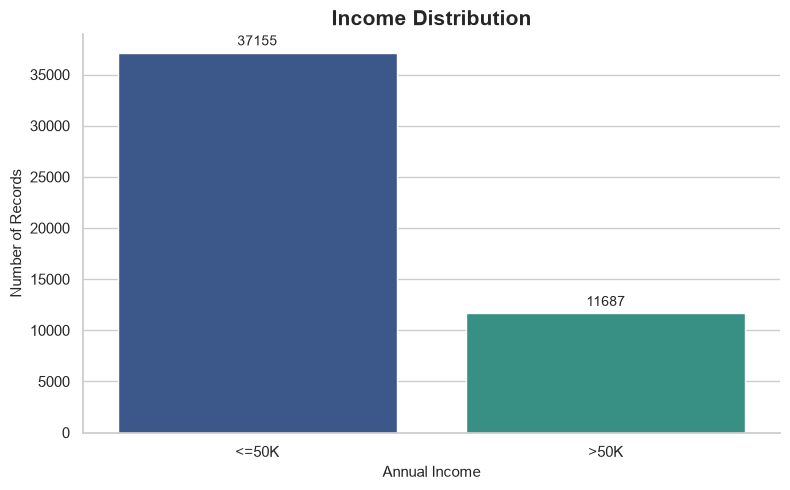

In [35]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=adult_df,
    x="income",
    order=["<=50K", ">50K"],
    hue="income",
    palette=PROJECT_COLORS,
    legend=False
)

plt.title("Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Records")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

The income distribution shows that 76.07% of the records have an annual income of $50K or less, while 23.93% have an annual income above $50K.

This indicates that the dataset is imbalanced toward the `<=50K` income group. This imbalance should be considered in any future predictive modeling or classification analysis.

The analysis in this notebook focuses on descriptive patterns and associations and does not imply that any characteristic causes higher income.

## 8.2 Income Distribution by Sex

This analysis compares income groups across sex categories to identify differences
in the proportion of records earning above $50K.

The comparison is descriptive and should not be interpreted as evidence of causation.

In [36]:
sex_income = pd.crosstab(
    adult_df["sex"],
    adult_df["income"],
    normalize="index"
).mul(100).round(2)

sex_income

income,<=50K,>50K
sex,,
Female,89.07,10.93
Male,69.62,30.38


### Income Distribution by Sex Visualization

The 100% stacked bar chart compares the proportion of each income group within
the Female and Male categories. This allows the income distribution to be
compared independently of the different group sizes.

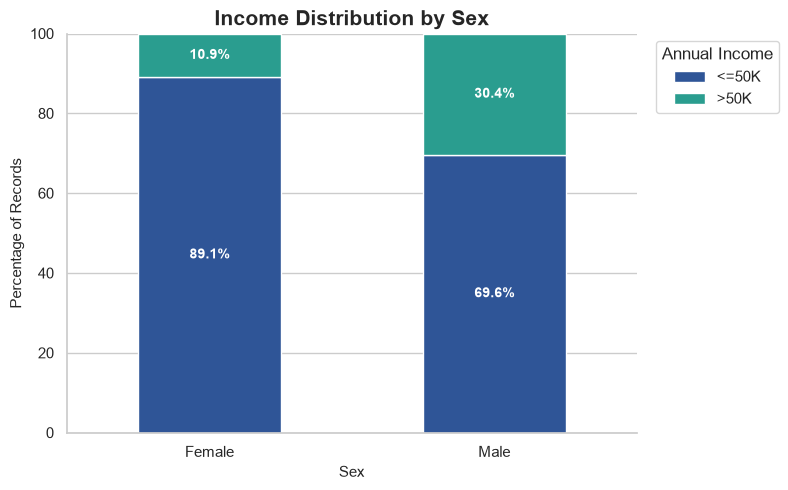

In [37]:
sex_income_plot = pd.crosstab(
    adult_df["sex"],
    adult_df["income"],
    normalize="index"
).mul(100)

ax = sex_income_plot[
    ["<=50K", ">50K"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=[
        PROJECT_COLORS["<=50K"],
        PROJECT_COLORS[">50K"]
    ]
)

plt.title("Income Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage of Records")
plt.xticks(rotation=0)
plt.ylim(0, 100)

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() > 5 else ""
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontweight="bold"
    )

plt.legend(
    title="Annual Income",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

The income distribution differs across the two sex categories in the dataset.

Among female records, 10.93% are in the `>50K` income group, compared with 30.38%
among male records. Conversely, 89.07% of female records and 69.62% of male
records are in the `<=50K` income group.

These results describe an association observed in the dataset and do not imply
that sex itself causes differences in income.

## 8.3 Income Distribution by Education

This analysis examines how the proportion of records earning above $50K varies
across education levels.

Because education categories have different numbers of records, the analysis
uses percentages within each education category rather than raw counts.

In [38]:
education_income = pd.crosstab(
    adult_df["education"],
    adult_df["income"],
    normalize="index"
).mul(100).round(2)

education_income

income,<=50K,>50K
education,,
10th,93.74,6.26
11th,94.92,5.08
12th,92.69,7.31
1st-4th,96.76,3.24
5th-6th,94.70,5.30
7th-8th,93.51,6.49
9th,94.58,5.42
Assoc-acdm,74.20,25.80
Assoc-voc,74.67,25.33


### Income Above $50K by Education Level

The following horizontal bar chart compares the percentage of records earning
above $50K across education levels.

Education levels are arranged according to the dataset's education hierarchy
to make the pattern easier to interpret.

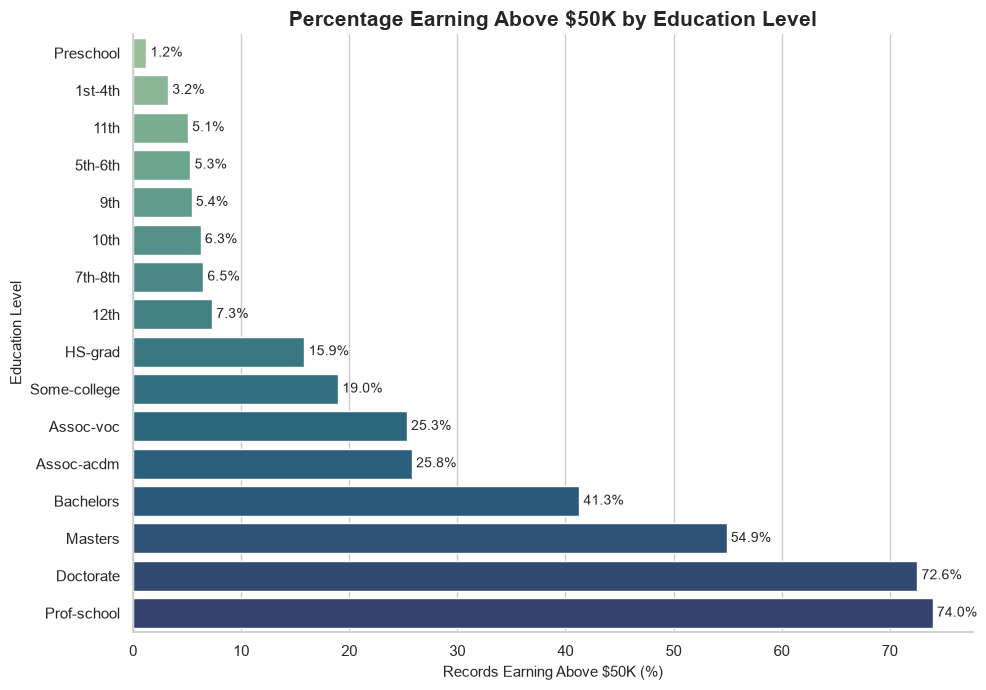

In [39]:
education_income_plot = (
    adult_df.groupby("education", observed=True)["high_income"]
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    x=education_income_plot.values,
    y=education_income_plot.index,
    hue=education_income_plot.index,
    palette="crest",
    legend=False
)

plt.title("Percentage Earning Above $50K by Education Level")
plt.xlabel("Records Earning Above $50K (%)")
plt.ylabel("Education Level")

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

The percentage of records earning above $50K varies substantially across
education levels.

Lower education categories generally have a smaller proportion of records in
the `>50K` income group. For example, Preschool has 1.20%, while 1st-4th,
11th, and 12th have 3.24%, 5.08%, and 7.31%, respectively.

The proportion increases for higher education categories. Among records with
a Bachelor's degree, 41.28% are in the `>50K` group, while the proportion is
54.91% for Master's, 72.56% for Doctorate, and 73.98% for Prof-school.

Overall, higher education levels are associated with a greater proportion of
records earning above $50K in this dataset. This is an observed association
and does not establish a causal relationship between education and income.

## 8.4 Income Distribution by Occupation

This analysis compares the percentage of records earning above $50K across
different occupation categories.

The analysis uses the proportion of high-income records within each occupation
rather than raw counts, allowing occupations with different group sizes to be
compared more fairly.

In [40]:
occupation_income = (
    adult_df.groupby("occupation", observed=True)["high_income"]
    .mean()
    .mul(100)
    .sort_values()
    .round(2)
)

occupation_income

occupation
Priv-house-serv       1.24
Other-service         4.14
Handlers-cleaners     6.66
Unknown               9.43
Farming-fishing      11.61
Machine-op-inspct    12.31
Adm-clerical         13.69
Transport-moving     20.42
Craft-repair         22.63
Sales                26.80
Tech-support         29.05
Protective-serv      31.33
Armed-Forces         33.33
Prof-specialty       45.11
Exec-managerial      47.78
Name: high_income, dtype: float64

### Income Above $50K by Occupation

The following horizontal bar chart compares the percentage of records earning
above $50K across occupation categories.

Occupations are ordered from the lowest to the highest proportion of
high-income records to make differences easier to compare.

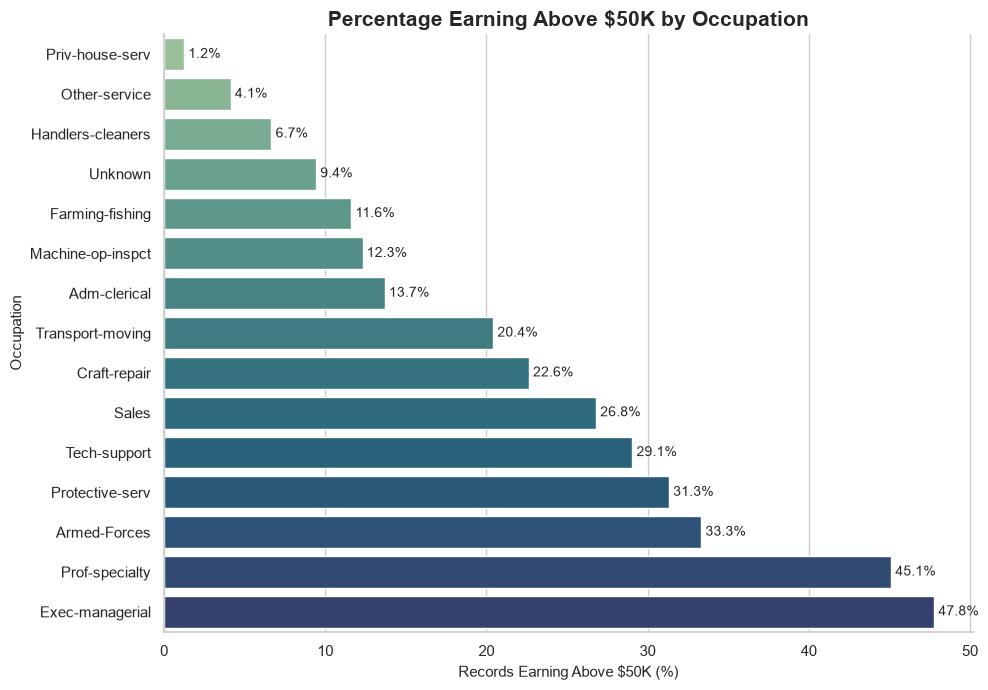

In [41]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    x=occupation_income.values,
    y=occupation_income.index,
    hue=occupation_income.index,
    palette="crest",
    legend=False
)

plt.title("Percentage Earning Above $50K by Occupation")
plt.xlabel("Records Earning Above $50K (%)")
plt.ylabel("Occupation")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

The proportion of records earning above $50K varies substantially across
occupation categories.

The highest proportions are observed in Exec-managerial (47.78%) and
Prof-specialty (45.11%), while Priv-house-serv (1.24%) and Other-service
(4.14%) have the lowest proportions.

Several occupations, including Protective-serv, Armed-Forces, Tech-support,
and Sales, fall between these extremes.

Overall, occupation shows a notable association with the income group in this
dataset. However, these results are descriptive and do not imply that
occupation alone determines income.

## 8.5 Income Distribution by Workclass

This analysis compares the percentage of records earning above $50K across
different workclass categories.

Percentages are calculated within each workclass category so that groups with
different numbers of records can be compared fairly.

In [42]:
workclass_income = (
    adult_df.groupby("workclass", observed=True)["high_income"]
    .mean()
    .mul(100)
    .sort_values()
    .round(2)
)

workclass_income

workclass
Never-worked         0.00
Unknown              9.47
Without-pay          9.52
Private             21.79
State-gov           26.75
Self-emp-not-inc    27.89
Local-gov           29.56
Federal-gov         39.18
Self-emp-inc        55.34
Name: high_income, dtype: float64

### Income Above $50K by Workclass

The following horizontal bar chart compares the percentage of records earning
above $50K across workclass categories.

Workclass categories are ordered from the lowest to the highest proportion of
high-income records for easier comparison.

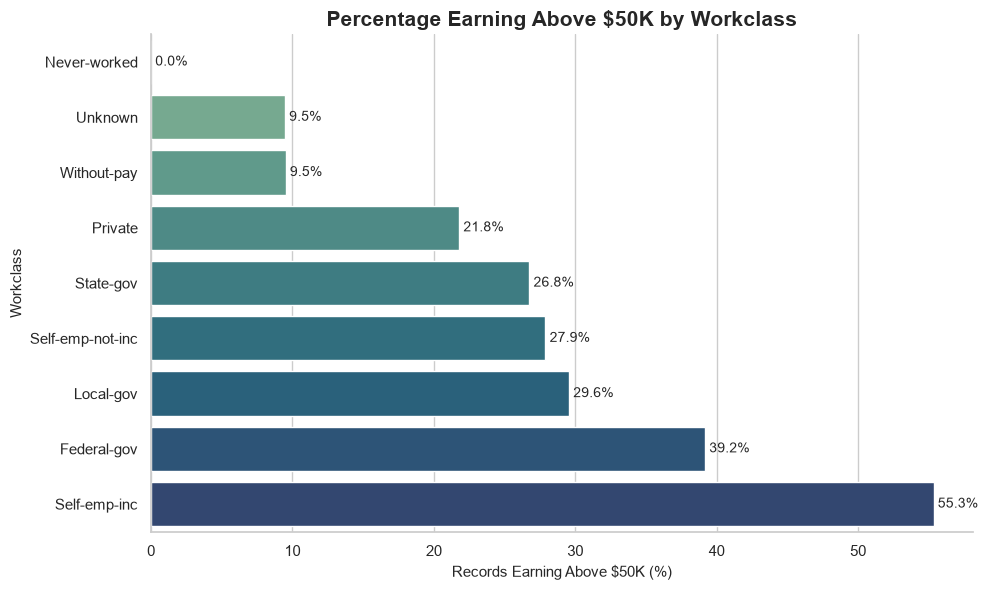

In [43]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=workclass_income.values,
    y=workclass_income.index,
    hue=workclass_income.index,
    palette="crest",
    legend=False
)

plt.title("Percentage Earning Above $50K by Workclass")
plt.xlabel("Records Earning Above $50K (%)")
plt.ylabel("Workclass")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

The proportion of records earning above $50K varies across workclass
categories.

Self-emp-inc has the highest proportion of records earning above $50K at
55.34%, followed by Federal-gov at 39.18%. Private records have a
high-income proportion of 21.79%.

Never-worked has 0% of records in the `>50K` group, while Unknown and
Without-pay have proportions below 10%.

Overall, workclass shows an association with income group in this dataset.
However, these results are descriptive and should not be interpreted as
evidence that workclass alone determines income.

## 8.6 Income Distribution by Age Group

This analysis examines how the proportion of records earning above $50K varies
across different age groups.

Percentages are calculated within each age group so that groups of different
sizes can be compared fairly.

In [44]:
age_income = (
    adult_df.groupby("age_group", observed=True)["high_income"]
    .mean()
    .mul(100)
    .round(2)
)

age_income

age_group
17-25     1.76
26-35    18.70
36-45    34.56
46-55    39.24
56-65    31.41
66+      19.80
Name: high_income, dtype: float64

### Income Above $50K by Age Group

The following bar chart compares the percentage of records earning above $50K
across age groups.

The age groups are displayed in chronological order to highlight how the
observed high-income proportion changes across different age ranges.

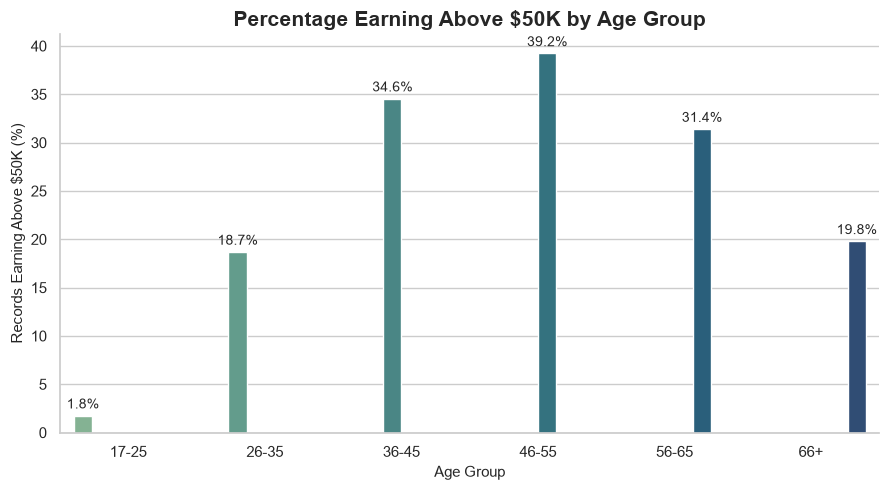

In [45]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=age_income.index,
    y=age_income.values,
    hue=age_income.index,
    palette="crest",
    legend=False
)

plt.title("Percentage Earning Above $50K by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Records Earning Above $50K (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

The proportion of records earning above $50K varies noticeably across age
groups.

The `18-25` group has the lowest proportion at 1.76%. The proportion increases
to 18.70% for `26-35`, 34.56% for `36-45`, and reaches a peak of 39.24% for
`46-55`.

After the 46-55 age group, the proportion decreases to 31.41% for `56-65`
and 19.80% for `66+`.

Overall, the dataset shows an association between age group and the proportion
of records earning above $50K. The highest observed proportion occurs in the
46-55 age group. These results are descriptive and do not imply that age alone
determines income.

## 8.7 Working Hours Distribution by Income Group

This analysis examines how weekly working hours are distributed across the two
income groups.

Working hours are grouped into meaningful ranges to make differences in the
distribution easier to interpret.

In [46]:
hours_income = pd.crosstab(
    adult_df["hours_group"],
    adult_df["income"],
    normalize="columns"
).mul(100).round(2)

hours_income

income,<=50K,>50K
hours_group,,
<=20,11.17,2.58
21-34,9.86,2.39
35-40,55.79,45.91
41-49,8.22,13.84
50-59,8.77,22.00
60+,6.19,13.29


### Working Hours Distribution by Income Group Visualization

The following grouped bar chart compares the distribution of weekly working-hour
ranges between the `<=50K` and `>50K` income groups.

Percentages are calculated within each income group, allowing the distributions
to be compared despite the different sizes of the two income categories.

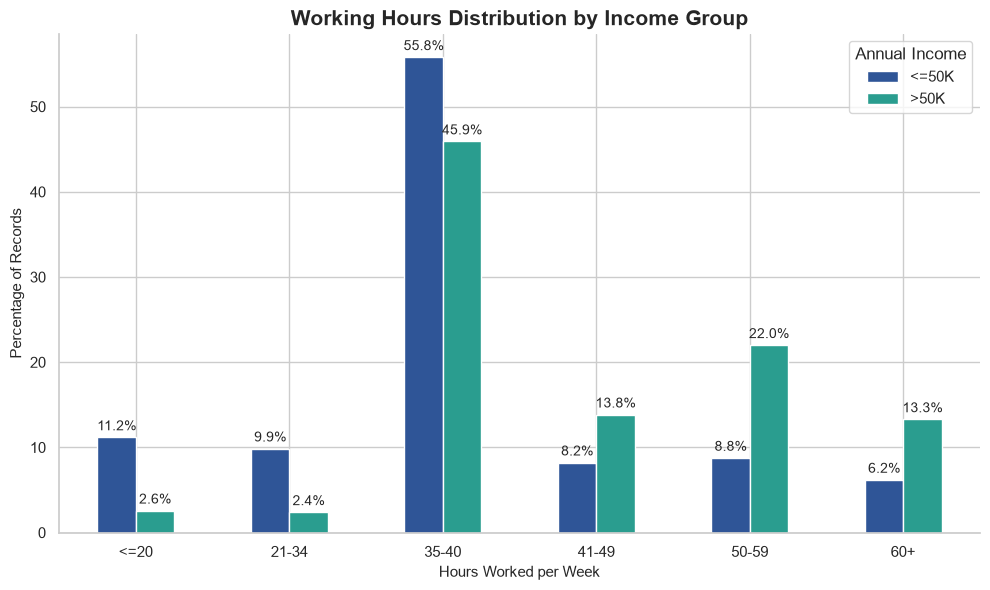

In [47]:
hours_income_plot = pd.crosstab(
    adult_df["hours_group"],
    adult_df["income"],
    normalize="columns"
).mul(100)

ax = hours_income_plot[
    ["<=50K", ">50K"]
].plot(
    kind="bar",
    figsize=(10, 6),
    color=[
        PROJECT_COLORS["<=50K"],
        PROJECT_COLORS[">50K"]
    ]
)

plt.title("Working Hours Distribution by Income Group")
plt.xlabel("Hours Worked per Week")
plt.ylabel("Percentage of Records")
plt.xticks(rotation=0)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.legend(
    title="Annual Income"
)

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

The distribution of weekly working hours differs between the two income groups.

The `35-40` hours category represents the largest share of both groups,
accounting for 55.79% of the `<=50K` group and 45.91% of the `>50K` group.

Higher working-hour categories are more prevalent within the `>50K` group.
For example, 22.00% of the `>50K` group works 50-59 hours per week,
compared with 8.77% of the `<=50K` group. Similarly, 13.29% of the
`>50K` group works 60 or more hours, compared with 6.19% of the `<=50K`
group.

Overall, the dataset shows an association between weekly working hours and
income group, particularly among records working longer hours. These results
are descriptive and do not imply that working more hours causes higher income.

## 8.8 Numeric Variable Analysis

This section examines the distributions and relationships of the main numeric
variables in the dataset.

Summary statistics are used to understand the central tendency, spread, and
range of the variables before investigating their relationships with income.

### 8.8.1 Summary Statistics

The following summary provides descriptive statistics for the main numeric
variables used in the analysis.

In [48]:
numeric_eda_columns = [
    "age",
    "education_num",
    "hours_per_week",
    "capital_gain",
    "capital_loss",
    "net_capital"
]

adult_df[numeric_eda_columns].describe().round(2)

,age,education_num,hours_per_week,capital_gain,capital_loss,net_capital
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,10.08,40.42,1079.07,87.5,991.57
std,13.71,2.57,12.39,7452.02,403.0,7475.55
min,17.00,1.00,1.00,0.00,0.0,-4356.00
25%,28.00,9.00,40.00,0.00,0.0,0.00
50%,37.00,10.00,40.00,0.00,0.0,0.00
75%,48.00,12.00,45.00,0.00,0.0,0.00
max,90.00,16.00,99.00,99999.00,4356.0,99999.00


### 8.8.2 Age Distribution by Income Group

This analysis compares the distribution of age between the `<=50K` and `>50K`
income groups.

The distribution provides additional detail beyond the age-group comparison
and helps identify differences in the typical ages represented within each
income category.

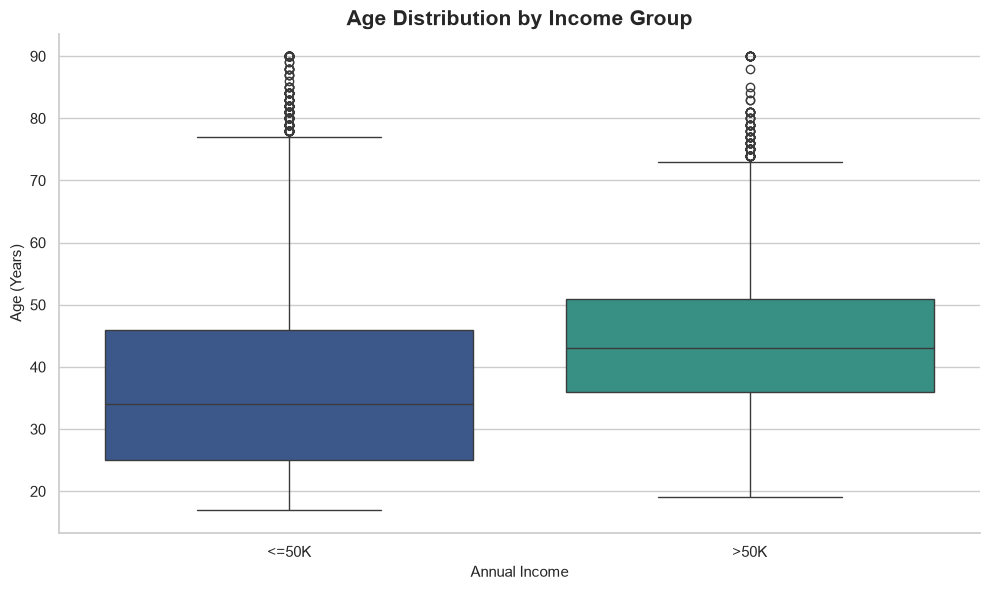

In [49]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=adult_df,
    x="income",
    y="age",
    hue="income",
    palette=PROJECT_COLORS,
    legend=False
)

plt.title("Age Distribution by Income Group")
plt.xlabel("Annual Income")
plt.ylabel("Age (Years)")

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

The age distribution differs between the two income groups.

The median age of the `>50K` group is higher than that of the `<=50K` group,
indicating that higher-income records tend to be associated with older ages in
this dataset.

The `<=50K` group has a median age of approximately 34 years, while the `>50K`
group has a median age of approximately 43 years. The `>50K` group is also
generally shifted toward higher ages.

Both income groups contain observations at older ages that appear as outliers
in the box plot. These observations are retained because they represent valid
records in the dataset.

Overall, age shows a noticeable association with income group in this dataset,
but this descriptive relationship does not imply that age alone determines
income.

### 8.8.3 Education Level Representation by Income Group

The `education_num` variable represents education levels numerically.

This analysis compares the distribution of education numbers between the two
income groups to examine whether higher numeric education levels are more
common among records earning above $50K.

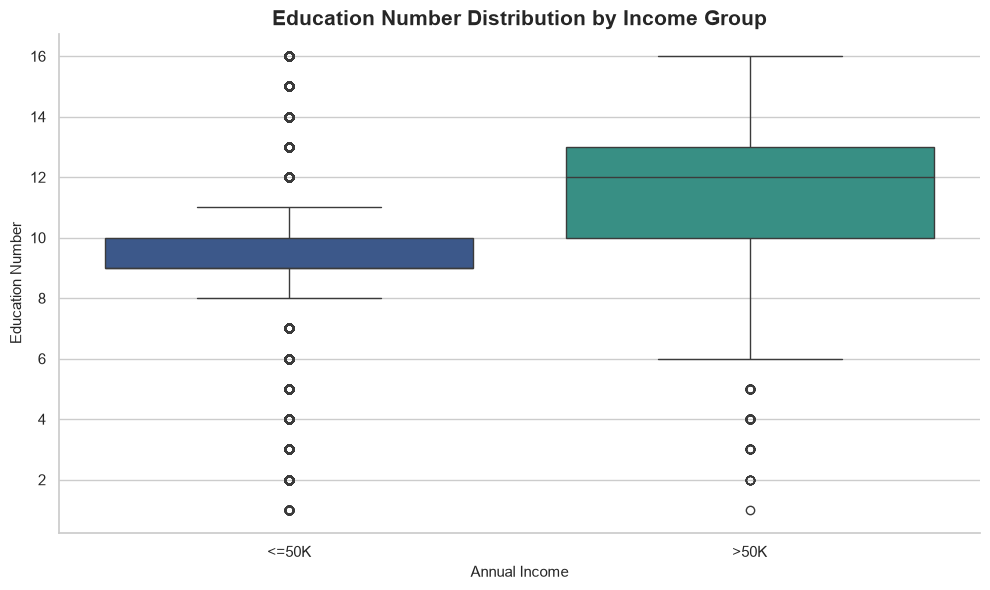

In [50]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=adult_df,
    x="income",
    y="education_num",
    hue="income",
    palette=PROJECT_COLORS,
    legend=False
)

plt.title("Education Number Distribution by Income Group")
plt.xlabel("Annual Income")
plt.ylabel("Education Number")

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

The distribution of `education_num` differs substantially between the two
income groups.

The `<=50K` group has a median education number of approximately 9, while the
`>50K` group has a median of approximately 12. The middle 50% of the `>50K`
group is also concentrated at higher education-number values.

This indicates that higher education-number levels are associated with a
greater representation of records earning above $50K in this dataset.

The plot also shows observations at lower and higher education-number levels
outside the main ranges of the distributions. These records are retained
because they represent valid observations in the dataset.

Overall, education level shows a strong descriptive association with income
group, but the relationship should not be interpreted as evidence that
education alone determines income.

### 8.8.4 Weekly Working Hours by Income Group

This analysis compares the distribution of actual weekly working hours between
the `<=50K` and `>50K` income groups.

A box plot is used to compare the median, spread, and potential outliers of
weekly working hours.

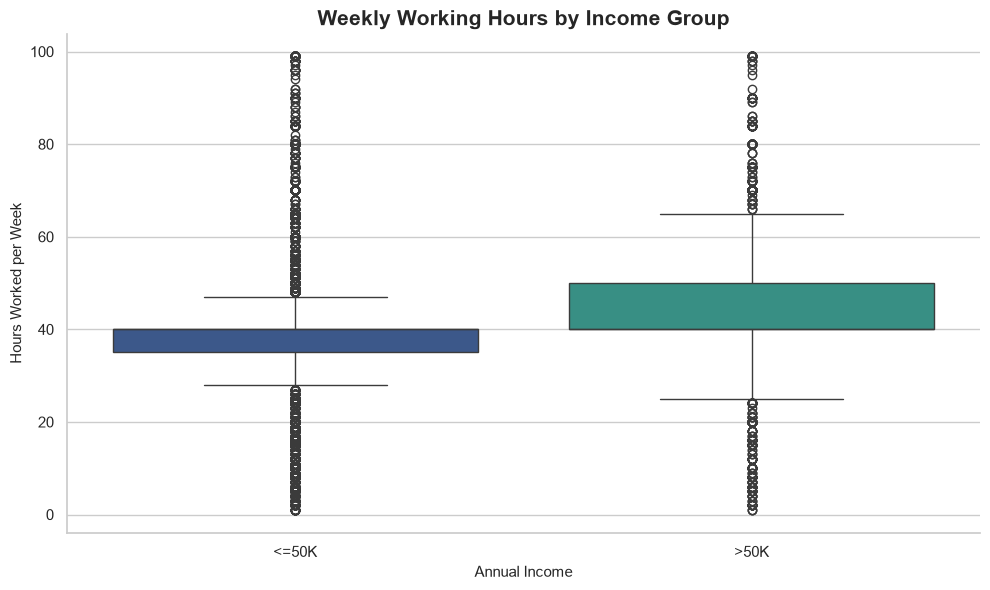

In [51]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=adult_df,
    x="income",
    y="hours_per_week",
    hue="income",
    palette=PROJECT_COLORS,
    legend=False
)

plt.title("Weekly Working Hours by Income Group")
plt.xlabel("Annual Income")
plt.ylabel("Hours Worked per Week")

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

The distribution of weekly working hours differs between the two income groups.

The `>50K` group has a higher median number of weekly working hours than the
`<=50K` group. Its middle 50% of observations is also shifted toward higher
working-hour values.

Both groups contain observations with unusually low and high working hours,
which appear as outliers in the box plot. These observations are retained
because they are valid records in the dataset.

Overall, weekly working hours show a descriptive association with income group,
with the `>50K` group generally exhibiting higher working-hour values.
However, this does not imply that working more hours causes higher income.

### 8.8.5 Numeric Correlation Analysis

Correlation analysis is used to examine the linear relationships between the
main numeric variables in the dataset.

The correlation coefficient ranges from -1 to +1. Values closer to +1 indicate
a stronger positive linear relationship, while values closer to -1 indicate a
stronger negative linear relationship. Values near 0 indicate a weak linear
relationship.

Correlation does not imply causation.

In [52]:
correlation_columns = [
    "age",
    "education_num",
    "hours_per_week",
    "capital_gain",
    "capital_loss",
    "net_capital",
    "high_income"
]

correlation_matrix = adult_df[correlation_columns].corr()

correlation_matrix.round(2)

,age,education_num,hours_per_week,capital_gain,capital_loss,net_capital,high_income
age,1.00,0.03,0.07,0.08,0.06,0.07,0.23
education_num,0.03,1.00,0.14,0.13,0.08,0.12,0.33
hours_per_week,0.07,0.14,1.00,0.08,0.05,0.08,0.23
capital_gain,0.08,0.13,0.08,1.00,-0.03,1.00,0.22
capital_loss,0.06,0.08,0.05,-0.03,1.00,-0.09,0.15
net_capital,0.07,0.12,0.08,1.00,-0.09,1.00,0.21
high_income,0.23,0.33,0.23,0.22,0.15,0.21,1.00


### Correlation Heatmap

The following heatmap visualizes the linear correlations among the main numeric
variables and the high-income indicator.

The heatmap helps identify variables that have stronger positive or negative
linear relationships with the income outcome and with each other.

<Axes: >

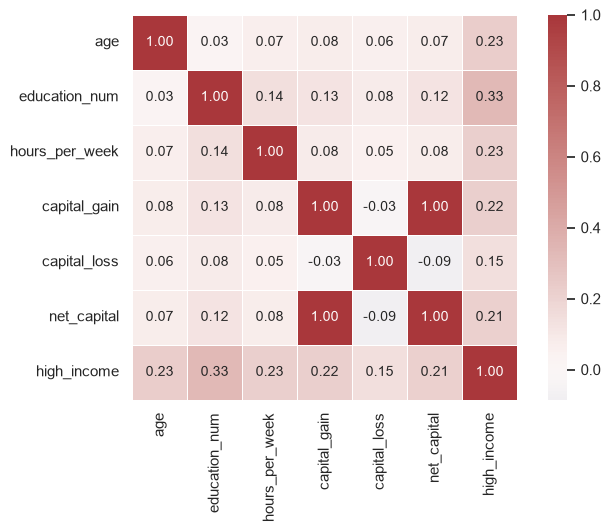

In [53]:
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    square=True

)


## 8.9 Capital Gain and Capital Loss Analysis

Capital gain and capital loss contain many zero values and a smaller number of
large observations.

This section examines how frequently records contain non-zero capital gain or
capital loss before comparing these variables with income.


### 8.9.1 Records with Non-Zero Capital Gain or Loss

The following analysis measures the number and percentage of records with
non-zero capital gain and non-zero capital loss.

In [54]:
capital_summary = pd.DataFrame({
    "count": [
        (adult_df["capital_gain"] > 0).sum(),
        (adult_df["capital_loss"] > 0).sum()
    ],
    "percentage": [
        (adult_df["capital_gain"] > 0).mean() * 100,
        (adult_df["capital_loss"] > 0).mean() * 100
    ]
}, index=["Capital Gain", "Capital Loss"])

capital_summary.round(2)

,count,percentage
Capital Gain,4035,8.26
Capital Loss,2282,4.67


### 8.9.2 Non-Zero Capital Gain and Loss Visualization

The following bar chart compares the percentage of records with non-zero
capital gain and non-zero capital loss.

The comparison highlights the prevalence of these financial variables in the
dataset.

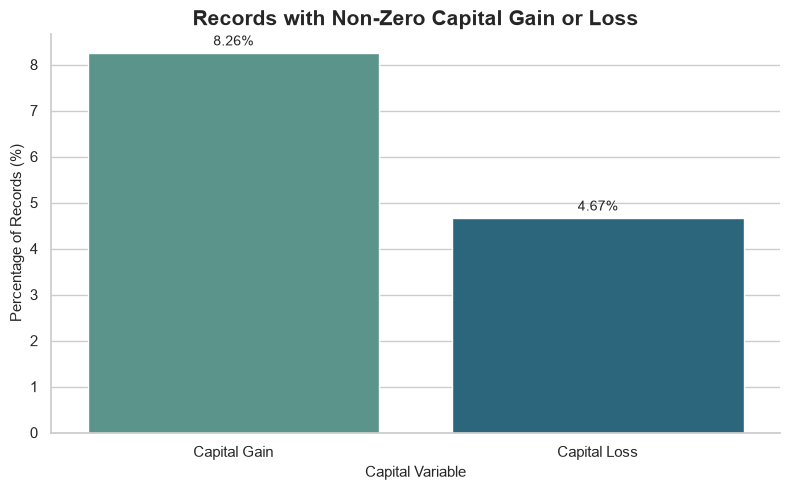

In [55]:
capital_plot = capital_summary["percentage"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=capital_plot.index,
    y=capital_plot.values,
    hue=capital_plot.index,
    palette="crest",
    legend=False
)

plt.title("Records with Non-Zero Capital Gain or Loss")
plt.xlabel("Capital Variable")
plt.ylabel("Percentage of Records (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

Non-zero capital gain is present in 8.26% of the records, while non-zero
capital loss is present in 4.67% of the records.

This indicates that the majority of records have zero values for both capital
gain and capital loss. Capital gain is more common than capital loss in the
dataset.

Because these variables contain many zero values and a relatively small number
of large observations, their distributions are highly skewed. Therefore,
summary statistics such as the mean should be interpreted alongside the median
and distribution.

These observations describe the structure of the dataset and do not imply
that capital gain or loss causes higher income.

### 8.9.3 Capital Gain and Loss by Income Group

The following analysis compares the percentage of records with non-zero
capital gain and non-zero capital loss across the two income groups.

This helps identify whether the presence of capital gain or capital loss
differs between the `<=50K` and `>50K` income groups.

In [56]:
capital_income = pd.DataFrame({
    "Capital Gain": adult_df.groupby("income")["capital_gain"].apply(
        lambda x: (x > 0).mean() * 100
    ),
    "Capital Loss": adult_df.groupby("income")["capital_loss"].apply(
        lambda x: (x > 0).mean() * 100
    )
}).round(2)

capital_income

,Capital Gain,Capital Loss
income,,
<=50K,4.16,3.06
>50K,21.31,9.79


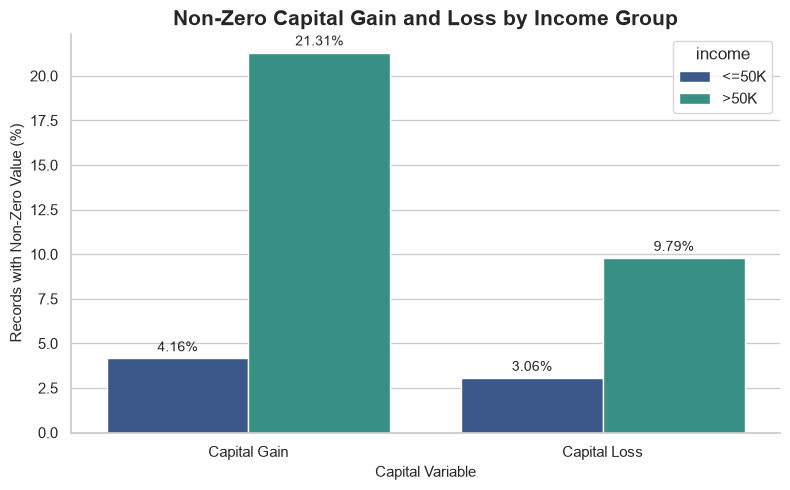

In [57]:
capital_income_plot = capital_income.reset_index().melt(
    id_vars="income",
    var_name="Capital Variable",
    value_name="Percentage"
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=capital_income_plot,
    x="Capital Variable",
    y="Percentage",
    hue="income",
    hue_order=["<=50K", ">50K"],
    palette=PROJECT_COLORS
)

plt.title("Non-Zero Capital Gain and Loss by Income Group")
plt.xlabel("Capital Variable")
plt.ylabel("Records with Non-Zero Value (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

The presence of non-zero capital gain and capital loss is higher among records
in the `>50K` income group.

For capital gain, 21.31% of records in the `>50K` group have a non-zero value,
compared with 4.16% in the `<=50K` group. Similarly, 9.79% of records in the
`>50K` group have a non-zero capital loss, compared with 3.06% in the `<=50K`
group.

Overall, capital gain and capital loss show an association with the income
group in this dataset, with non-zero values being more prevalent among
higher-income records.

These results are descriptive and do not imply that capital gain or capital
loss causes higher income.

## 8.10 Key Findings from EDA

The exploratory analysis identified several notable patterns in the Adult
Income dataset:

- **Income distribution:** 76.07% of records belong to the `<=50K` income
  group, while 23.93% belong to the `>50K` group.

- **Education:** Higher education levels are generally associated with a
  greater proportion of records earning above $50K. The `>50K` proportion is
  particularly high among records with Master's, Doctorate, and Prof-school
  education levels.

- **Occupation:** Income distribution varies substantially across occupations.
  `Exec-managerial` and `Prof-specialty` have some of the highest proportions
  of records in the `>50K` group.

- **Workclass:** The proportion of records earning above $50K differs across
  workclass categories, with `Self-emp-inc` showing the highest observed
  proportion.

- **Age:** The proportion of records earning above $50K increases across the
  younger age groups and reaches its highest level in the `46-55` group at
  39.24%. It then decreases among older age groups.

- **Working hours:** The `>50K` income group has a greater representation in
  higher weekly working-hour categories, particularly among records working
  50-59 and 60+ hours per week.

- **Numeric variables:** `education_num` has the strongest positive
  correlation with `high_income` among the numeric variables examined, with a
  correlation of 0.33. Age and weekly working hours each have a correlation of
  0.23.

- **Capital variables:** Non-zero capital gain and capital loss are more
  prevalent among records in the `>50K` income group. Non-zero capital gain is
  present in 21.31% of the `>50K` group compared with 4.16% of the `<=50K`
  group.

These findings describe associations observed in the dataset. They should not
be interpreted as evidence that any individual characteristic causes higher
income.

### Overall EDA Takeaway

Overall, education, occupation, workclass, age, weekly working hours, and
capital-related variables show noticeable differences across income groups.

Among the numeric variables examined, education level shows the strongest
positive linear association with the high-income indicator.

These patterns provide useful insights for understanding the dataset and can
also guide feature selection and further analysis in a future predictive
modeling stage.

## 8.11 EDA Summary

The exploratory analysis examined the distribution of income across demographic,
education, employment, working-hour, and financial characteristics.

The analysis shows clear differences between the `<=50K` and `>50K` income
groups. Education, occupation, workclass, age, weekly working hours, and
capital-related variables all show noticeable associations with income group.

Higher education levels are generally associated with a greater proportion of
records earning above $50K. Income differences are also observed across
occupations and workclass categories.

The proportion of records earning above $50K increases across several age
groups and reaches its highest level in the `46-55` group. The `>50K` group also
shows a greater representation of longer weekly working hours.

Among the numeric variables examined, `education_num` has the strongest
positive correlation with the high-income indicator. Capital gain and capital
loss are also more frequently non-zero among records in the `>50K` group.

Overall, the EDA provides a descriptive understanding of the factors associated
with income in the dataset and establishes a foundation for further analysis.

### Transition to Final Project Findings

The EDA has now been completed. The following sections consolidate the major
findings, discuss the limitations of the analysis, and present the overall
conclusion of the project.

# 9. Key Findings

The main findings from the Adult Income analysis are:

1. The dataset is dominated by the `<=50K` income group, which represents
   76.07% of all records.

2. Higher education levels are generally associated with a higher proportion
   of records earning above $50K.

3. Income distribution varies considerably across occupation and workclass
   categories.

4. The `46-55` age group has the highest observed proportion of records earning
   above $50K at 39.24%.

5. Records in the `>50K` income group are more represented in higher weekly
   working-hour categories.

6. `education_num` has the strongest positive linear correlation with
   `high_income` among the numeric variables examined, with a correlation of
   0.33.

7. Non-zero capital gain and capital loss are more prevalent in the `>50K`
   income group.

These findings represent descriptive associations within the dataset and
should not be interpreted as causal relationships.

# 10. Limitations

The following limitations should be considered when interpreting the results of
this analysis:

1. **Descriptive analysis only:**  
   The analysis identifies patterns and associations in the dataset. It does
   not establish causal relationships between the observed characteristics and
   income.

2. **Historical dataset:**  
   The Adult Income dataset represents census-based information from a specific
   period. The observed relationships may not reflect current income patterns
   or economic conditions.

3. **Missing categorical values:**  
   Missing values represented by `?` were replaced with `Unknown`. This
   preserves the records but may limit the interpretation of categories with
   missing information.

4. **Duplicate records:**  
   Duplicate rows were retained because the dataset does not provide a unique
   identifier for individuals. Therefore, identical rows cannot be assumed to
   represent erroneous duplicates.

5. **Income threshold:**  
   Income is represented as two categories, `<=50K` and `>50K`. This does not
   provide information about the exact income of an individual.

6. **Potential confounding factors:**  
   Differences observed between income groups may be influenced by multiple
   characteristics simultaneously. The individual relationships examined in
   this EDA should therefore not be interpreted in isolation.

7. **Correlation limitations:**  
   Correlation measures describe linear relationships between numeric variables
   and do not capture all possible relationships. A low correlation does not
   necessarily mean that no relationship exists.

8. **No predictive modeling in this stage:**  
   This notebook focuses on data cleaning and exploratory analysis. Predictive
   performance, feature importance, and model generalization are outside the
   scope of the current analysis.

### Analytical Scope

The results in this notebook should be interpreted as descriptive insights
from the Adult Income dataset. They provide a foundation for future statistical
analysis or predictive modeling but should not be used to make causal claims
about individual income.

# 11. Conclusion

This project performed data cleaning and exploratory data analysis on the Adult
Income dataset to understand which demographic, education, employment, working
hour, and financial characteristics are associated with annual income above
$50K.

The analysis found noticeable differences in income distribution across
education levels, occupations, workclass categories, age groups, sex, weekly
working hours, and capital-related variables.

Higher education levels generally showed a greater proportion of records in the
`>50K` income group. The `46-55` age group had the highest observed proportion
of records earning above $50K at 39.24%. The `>50K` income group also showed a
greater representation of longer weekly working hours and non-zero capital
values.

Among the numeric variables examined, `education_num` showed the strongest
positive linear correlation with the high-income indicator, with a correlation
of 0.33.

The project also demonstrated a complete data-preparation workflow, including
combining the original dataset partitions, standardizing text values, handling
missing-value markers, normalizing income labels, validating numeric variables,
and creating useful analytical features.

Overall, the analysis provides a clear descriptive understanding of income
patterns within the dataset. The findings can serve as a foundation for future
statistical analysis or predictive modeling, while recognizing that the
observed relationships do not establish causation.

# 12. Export Cleaned Dataset

The cleaned and feature-engineered dataset is exported as a CSV file so that it
can be reused for further analysis or predictive modeling without repeating the data-cleaning steps.

In [58]:
from pathlib import Path

processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

output_path = processed_dir / "adult_income_cleaned.csv"

adult_df.to_csv(output_path, index=False)

print(f"Cleaned dataset exported to: {output_path}")
print(f"Final dataset shape: {adult_df.shape}")

Cleaned dataset exported to: data\processed\adult_income_cleaned.csv
Final dataset shape: (48842, 20)


In [59]:
processed_file = Path("data/processed/adult_income_cleaned.csv")

print("File exists:", processed_file.exists())
print("File size (KB):", round(processed_file.stat().st_size / 1024, 2))

File exists: True
File size (KB): 6279.23
